# Import Libraries



In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Dataset



In [23]:
columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price",
]

df = pd.read_csv("auto.csv", names=columns)

print(df.shape)
df.head(10)


(205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


# Dataset Shape



In [24]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Rows: 205
Columns: 26


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

In [26]:
print(df.shape)


(205, 26)


# First Ten Records



In [27]:
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


# Data Types



In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

# Descriptive Statistics



In [29]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


# Mean, Median and Standard Deviation


In [30]:
numeric_cols = df.select_dtypes(include=np.number)
print("\nStandard Deviation")
print(numeric_cols.std())


Standard Deviation
symboling              1.245307
wheel-base             6.021776
length                12.337289
width                  2.145204
height                 2.443522
curb-weight          520.680204
engine-size           41.642693
compression-ratio      3.972040
city-mpg               6.542142
highway-mpg            6.886443
dtype: float64


# Unique Values in Categorical Columns


In [31]:
categorical_cols = df.select_dtypes(include='object')

for col in categorical_cols.columns:
    print("\n",col)
    print(df[col].unique())


 normalized-losses
<StringArray>
[  '?', '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str

 make
<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str

 fuel-type
<StringArray>
['gas', 'diesel']
Length: 2, dtype: str

 aspiration
<StringArray>
['std', 'turbo']
Length: 2, dtype: str

 num-of-doors
<St

C:\Users\smits\AppData\Local\Temp\ipykernel_15964\2018015264.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object')


# Missing Value Treatment

In [32]:
df.replace("?", np.nan, inplace=True)

df.isnull().sum()


symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [33]:
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,NaN


# Missing Value Analysis


In [34]:
missing = df.isnull().sum()

missing[missing > 0]

normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

# Mean Imputation


In [35]:
for col in ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].mean())

# Mode Imputation


In [36]:
df['num-of-doors'] = df['num-of-doors'].fillna(
    df['num-of-doors'].mode()[0]
)

In [ ]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                4
dtype: int64

In [38]:
df.dropna(subset=["price"], inplace=True)


In [ ]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

# Data Type Conversion


In [40]:
df['price'] = pd.to_numeric(
    df['price'],
    errors='coerce'
)

df['horsepower'] = pd.to_numeric(
    df['horsepower'],
    errors='coerce'
)

df.info()

<class 'pandas.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          201 non-null    int64  
 1   normalized-losses  201 non-null    float64
 2   make               201 non-null    str    
 3   fuel-type          201 non-null    str    
 4   aspiration         201 non-null    str    
 5   num-of-doors       201 non-null    str    
 6   body-style         201 non-null    str    
 7   drive-wheels       201 non-null    str    
 8   engine-location    201 non-null    str    
 9   wheel-base         201 non-null    float64
 10  length             201 non-null    float64
 11  width              201 non-null    float64
 12  height             201 non-null    float64
 13  curb-weight        201 non-null    int64  
 14  engine-type        201 non-null    str    
 15  num-of-cylinders   201 non-null    str    
 16  engine-size        201 non-null    int64  

# Feature Engineering

In [41]:
df["city-L/100km"] = 235 / df["city-mpg"]

df[
    ['city-mpg','city-L/100km']
].head()

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


# Horsepower Binning

In [42]:
bins = np.linspace(
    df["horsepower"].min(),
    df["horsepower"].max(),
    4
)

labels = [
    "Low",
    "Medium",
    "High"
]

df["horsepower-binned"] = pd.cut(
    df["horsepower"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[
    ['horsepower','horsepower-binned']
].head()

,horsepower,horsepower-binned
0,111.0,Low
1,111.0,Low
2,154.0,Medium
3,102.0,Low
4,115.0,Low


# Feature Normalization


In [43]:
df["length-normalized"] = df["length"] / df["length"].max()

df[["length", "length-normalized"]].head()


,length,length-normalized
0,168.8,0.811148
1,168.8,0.811148
2,171.2,0.822681
3,176.6,0.848630
4,176.6,0.848630


# Price Distribution


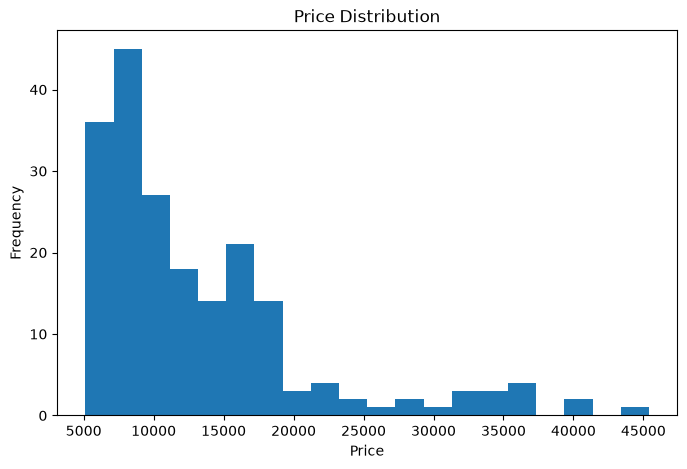

In [44]:
plt.figure(figsize=(8,5))

plt.hist(
    df['price'].dropna(),
    bins=20
)

plt.title(
    'Price Distribution'
)

plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

# Histogram Horsepower

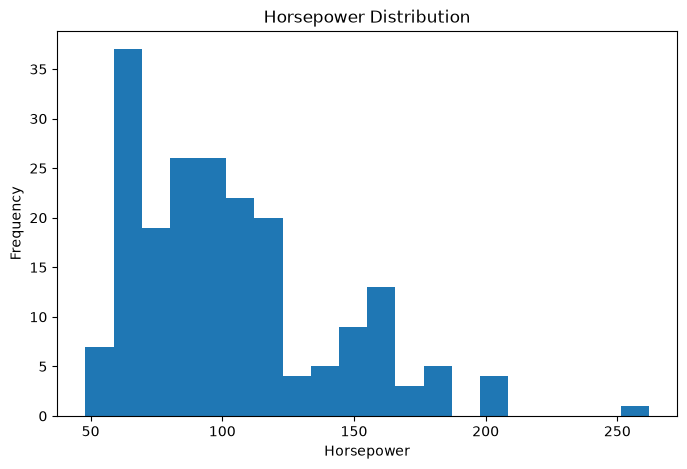

In [45]:
plt.figure(figsize=(8,5))

plt.hist(
    df['horsepower'].dropna(),
    bins=20
)

plt.title(
    'Horsepower Distribution'
)

plt.xlabel('Horsepower')
plt.ylabel('Frequency')

plt.show()

# Boxplot


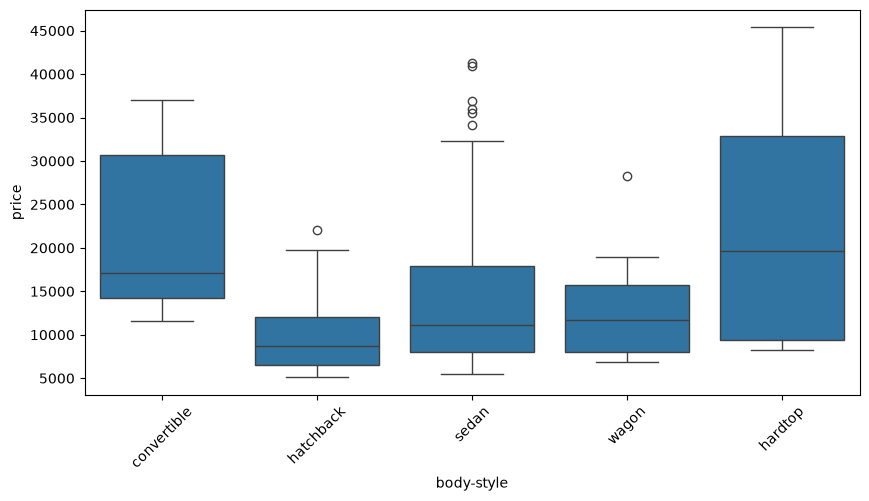

In [46]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='body-style',
    y='price',
    data=df
)

plt.xticks(rotation=45)

plt.show()

# Correlation Heatmap

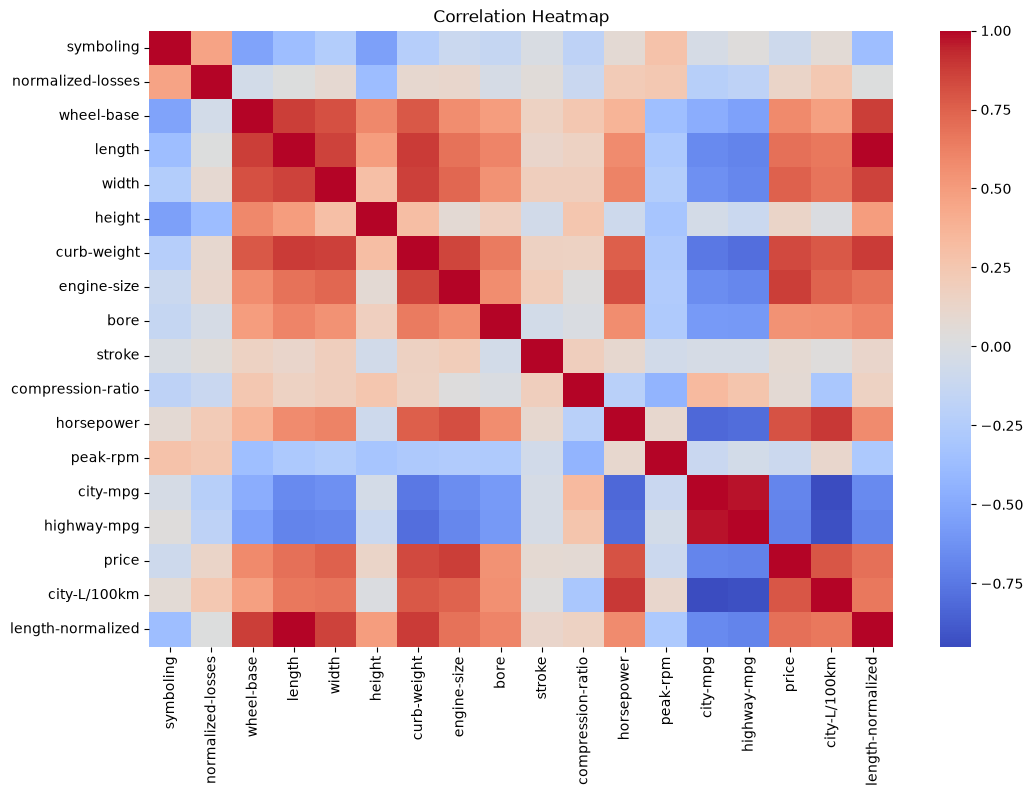

In [47]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# Feature Selection for Regression



In [48]:
df_reg = df.copy()

numeric_df = df_reg.select_dtypes(include=np.number)

X = numeric_df.drop('price', axis=1)

y = numeric_df['price']

print(X.shape)
print(y.shape)

(201, 17)
(201,)


# Train-Test Split (80/20)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)


(160, 17)
(41, 17)


# Linear Regression Model


In [50]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

print("Linear Regression Model Trained")

Linear Regression Model Trained


# Linear Regression Prediction


In [51]:
lr_pred = lr_model.predict(X_test)

print(lr_pred[:10])

[ 7509.00083993 25657.44314587  6281.03994304  7186.5253614
 14549.7700523   5616.06037236 26921.90497759  9363.15717403
 20664.89899863 30216.39244884]


# Linear Regression Evaluation


In [52]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)
lr_mse = mean_squared_error(
    y_test,
    lr_pred
)
lr_r2 = r2_score(
    y_test,
    lr_pred
)
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("R2 Score:", lr_r2)

MAE: 3404.4267513383697
MSE: 24782385.563925266
R2 Score: 0.7974414450050438


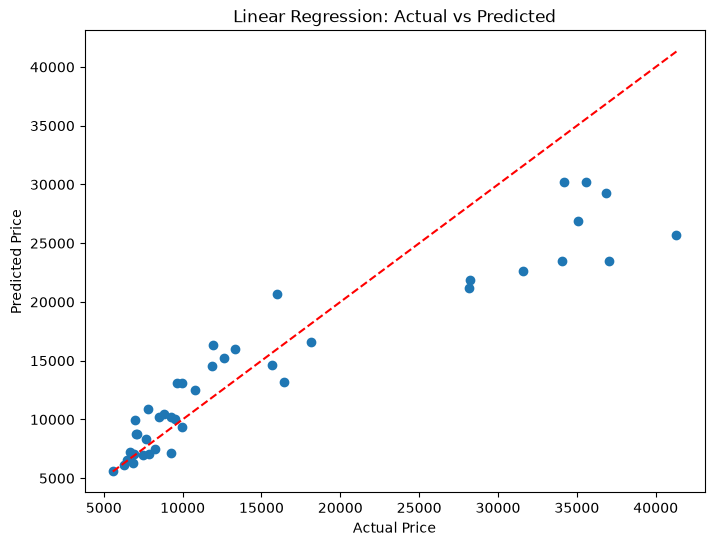

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lr_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()


# Random Forest Regressor


In [54]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print(
    "Random Forest Model Trained"
)

Random Forest Model Trained


In [55]:
rf_pred = rf_model.predict(X_test)


# Actual vs Predicted Prices


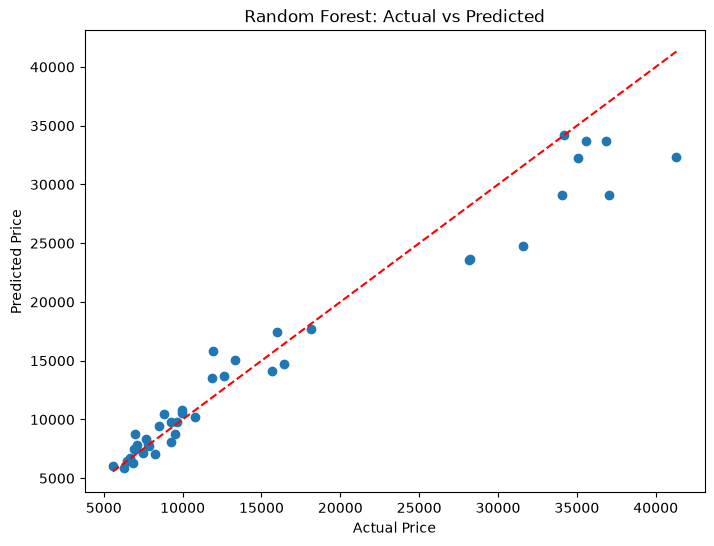

In [69]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")

plt.show()


# Random Forest Evaluation


In [56]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_mse = mean_squared_error(
    y_test,
    rf_pred
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)

MAE: 1799.6849918699186
MSE: 7862056.714481807
R2 Score: 0.9357395661823611


# Feature Importance


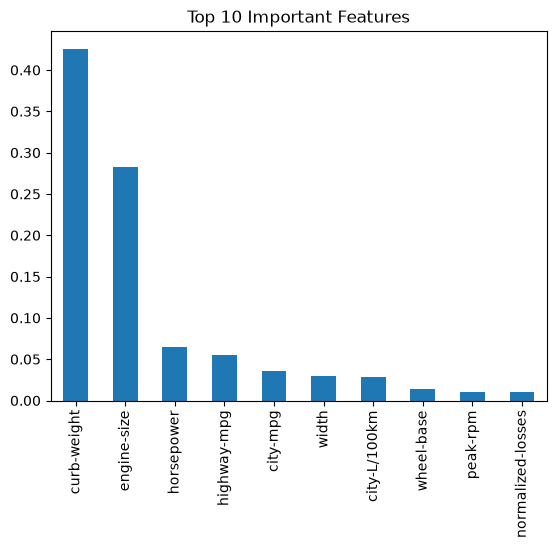

In [57]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
).head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

# Experiment with 70/30 Train-Test Split


In [58]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model2.fit(X_train2, y_train2)

pred2 = rf_model2.predict(X_test2)

print("R2 Score:", r2_score(y_test2, pred2))


R2 Score: 0.93478274696514


# Price Category Creation


In [59]:
df_class = df.copy()
df_class['price-category'] = pd.qcut(
    df_class['price'],
    3,
    labels=[
        'Low',
        'Medium',
        'High'
    ]
)
df_class[
    'price-category'
].value_counts()

price-category
Low       67
Medium    67
High      67
Name: count, dtype: int64

In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_class["price-category"] = le.fit_transform(df_class["price-category"])


In [61]:
X_cls = df_class[["horsepower", "engine-size", "curb-weight"]]

y_cls = df_class["price-category"]


In [62]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)


In [63]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_c, y_train_c)

print("Logistic Regression Trained")


Logistic Regression Trained


In [64]:
y_pred_c = log_model.predict(X_test_c)


# Classification Accuracy


In [65]:
acc = accuracy_score(
    y_test_c,
    y_pred_c
)
print("Accuracy:",acc)

Accuracy: 0.7804878048780488


In [66]:
print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        14
           1       0.80      0.86      0.83        14
           2       0.67      0.62      0.64        13

    accuracy                           0.78        41
   macro avg       0.77      0.78      0.77        41
weighted avg       0.78      0.78      0.78        41



# Confusion Matrix

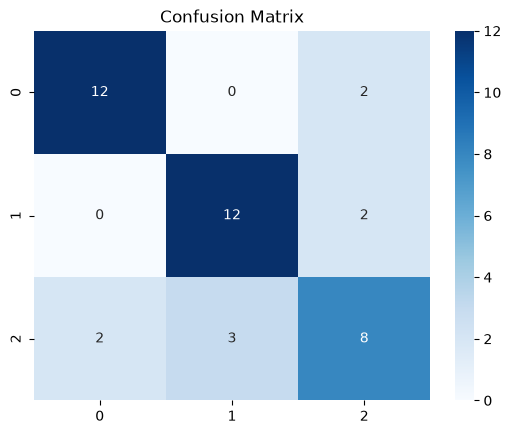

In [67]:
cm = confusion_matrix(y_test_c, y_pred_c)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.show()
